<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/08_VAR_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8 실습 A: 다변량 시계열과 VAR
**Notebook:** `08_VAR_forecasting.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 단변량 시계열과 다변량 시계열의 차이를 데이터로 확인합니다.
2. 여러 거시 변수의 동적 상호작용을 하나의 시스템으로 다루는 VAR 모형을 적합합니다.
3. 로그 차분을 통해 비정상 수준(Level) 데이터를 성장률(Growth rate)로 변환합니다.
4. ADF 검정으로 각 변수의 정상성을 점검합니다.
5. 정보 기준(AIC, BIC)을 사용하여 적절한 시차(lag) 수를 선택합니다.
6. VAR 모형으로 다변량 예측을 수행하고, 변수별 오차를 비교합니다.
7. 베이스라인 예측과 비교하여 VAR의 실무적 유용성을 판단합니다.

---

## 왜 이 실습이 중요한가?
단변량 ARIMA는 하나의 변수만 바라봅니다.  
그러나 현실의 경제와 경영 환경에서는 GDP, 소비, 투자, 금리, 환율, 매출 등 여러 변수들이 서로 영향을 주고받습니다.

VAR(Vector Autoregression)는 이러한 상호작용을 대칭적으로 다루는 가장 고전적인 다변량 시계열 모형입니다.  
이번 실습의 핵심은 단순히 함수를 실행하는 것이 아니라, **“각 변수의 과거가 다른 변수의 미래를 설명할 수 있는가?”**라는 다변량 사고방식을 익히는 데 있습니다.


In [1]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.  
마크다운 셀과 코드 주석은 한글로 유지합니다.


In [2]:
# ============================================
# 2. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 2. 실습용 거시경제 데이터 불러오기
이번 실습에서는 `statsmodels`에 포함된 **macrodata** 데이터를 사용합니다.

여기서 다음 세 변수를 선택합니다.

- `realgdp`: 실질 GDP
- `realcons`: 실질 소비
- `realinv`: 실질 투자

이 변수들은 모두 수준 데이터(level data)이므로, 그대로 사용하면 비정상일 가능성이 높습니다.  
따라서 먼저 로그 차분을 통해 성장률 시계열로 변환합니다.


In [3]:
# ============================================
# 3. Macrodata 로드
# ============================================

import statsmodels.api as sm

macro = sm.datasets.macrodata.load_pandas().data.copy()
print("Raw shape:", macro.shape)
display(macro.head())


Raw shape: (203, 14)


,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


## 3. 분기 인덱스 만들기와 성장률 변환
macrodata는 `year`와 `quarter`를 별도 컬럼으로 가지고 있습니다.  
이를 바탕으로 분기 인덱스를 만든 뒤, 로그 차분(log difference × 100)을 사용하여 성장률로 변환합니다.

이렇게 하면 각 변수는 “수준”이 아니라 “전기 대비 변화율”에 가까운 시계열이 됩니다.


In [4]:
# ============================================
# 4. 분기 인덱스 생성 + 로그 차분
# ============================================

dates = pd.date_range(start="1959-03-31", periods=len(macro), freq="QE")

data = pd.DataFrame({
    "gdp_growth": np.log(macro["realgdp"].values),
    "cons_growth": np.log(macro["realcons"].values),
    "inv_growth": np.log(macro["realinv"].values)
}, index=dates)

data = data.diff() * 100
data = data.dropna()

print("Transformed shape:", data.shape)
display(data.head())


Transformed shape: (202, 3)


,gdp_growth,cons_growth,inv_growth
1959-06-30,2.494213,1.528611,8.021268
1959-09-30,-0.119295,1.038598,-7.213104
1959-12-31,0.349453,0.108401,3.442511
1960-03-31,2.219018,0.953415,10.266377
1960-06-30,-0.468455,1.257243,-10.669385


## 4. 시계열 플롯 비교
다변량 시계열에서는 개별 변수 하나보다, 여러 변수의 흐름을 함께 보는 것이 중요합니다.  
아래 그래프를 통해 세 변수의 변동성과 공통 국면을 확인합니다.


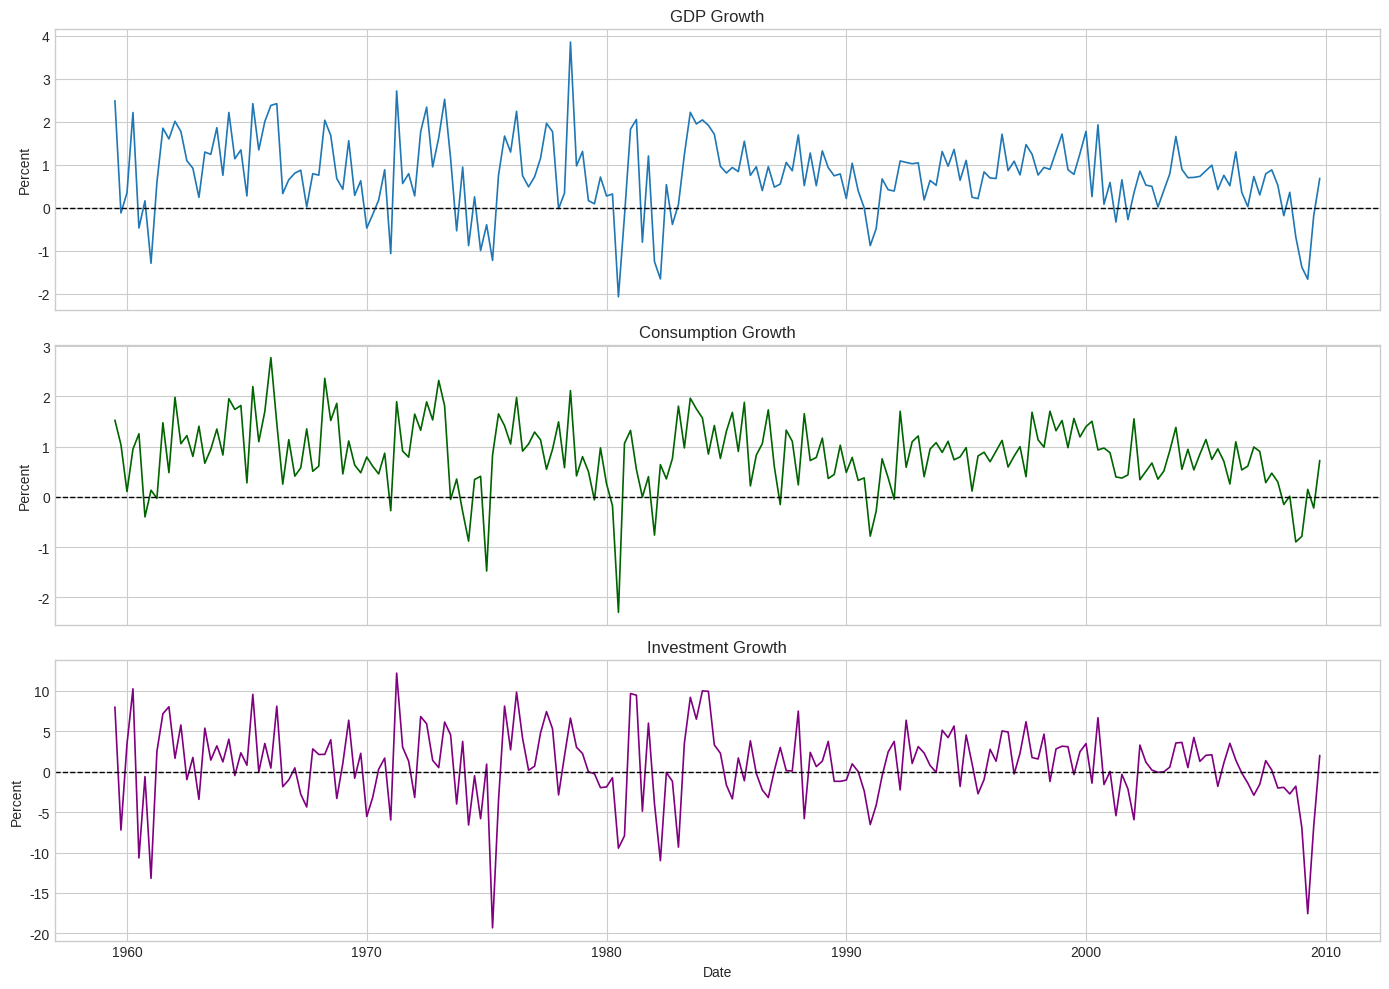

In [5]:
# ============================================
# 5. 다변량 시계열 플롯
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(data.index, data["gdp_growth"], linewidth=1.2)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("GDP Growth")
axes[0].set_ylabel("Percent")

axes[1].plot(data.index, data["cons_growth"], linewidth=1.2, color="darkgreen")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Consumption Growth")
axes[1].set_ylabel("Percent")

axes[2].plot(data.index, data["inv_growth"], linewidth=1.2, color="purple")
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Investment Growth")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Percent")

plt.tight_layout()
plt.show()


## 5. 정상성 점검
VAR는 원칙적으로 정상 시계열을 가정합니다.  
따라서 성장률로 변환한 데이터에 대해 ADF 검정을 수행합니다.

- 귀무가설: 단위근이 존재한다 (비정상)
- p-value가 작으면 정상성에 더 가까움


In [6]:
# ============================================
# 6. ADF 검정 함수
# ============================================

from statsmodels.tsa.stattools import adfuller

def adf_report(series, name="Series"):
    result = adfuller(pd.Series(series).dropna(), autolag="AIC")
    print(f"===== {name} =====")
    print("ADF Statistic :", round(result[0], 4))
    print("ADF p-value   :", round(result[1], 4))
    print("-" * 40)


In [7]:
# ============================================
# 7. 각 변수의 ADF 검정
# ============================================

for col in data.columns:
    adf_report(data[col], col)


===== gdp_growth =====
ADF Statistic : -6.9729
ADF p-value   : 0.0
----------------------------------------
===== cons_growth =====
ADF Statistic : -4.992
ADF p-value   : 0.0
----------------------------------------
===== inv_growth =====
ADF Statistic : -12.219
ADF p-value   : 0.0
----------------------------------------


## 6. 학습/테스트 분할
예측 성능을 보기 위해 마지막 8개 분기(2년)를 테스트 구간으로 둡니다.  
시계열이므로 무작위 분할이 아니라 **시간순 분할**을 사용합니다.


In [8]:
# ============================================
# 8. Train / Test split
# ============================================

test_size = 8

train = data.iloc[:-test_size]
test = data.iloc[-test_size:]

print("Train length:", len(train))
print("Test length :", len(test))

display(pd.DataFrame({
    "Train_End": [train.index.max()],
    "Test_Start": [test.index.min()],
    "Test_End": [test.index.max()]
}))


Train length: 194
Test length : 8


,Train_End,Test_Start,Test_End
0,2007-09-30,2007-12-31,2009-09-30


## 7. 베이스라인 예측
다변량 예측에서도 복잡한 모형은 베이스라인과 비교되어야 합니다.  
여기서는 각 변수에 대해 **Naive forecast**를 사용합니다.

즉, 테스트 구간의 모든 시점에 대해  
“마지막 관측값이 계속 유지된다”  
라고 예측합니다.


In [9]:
# ============================================
# 9. 다변량 Naive forecast
# ============================================

naive_forecast = pd.DataFrame(
    np.tile(train.iloc[-1].values, (len(test), 1)),
    index=test.index,
    columns=test.columns
)

display(naive_forecast.head())


,gdp_growth,cons_growth,inv_growth
2007-12-31,0.883185,0.473505,0.197611
2008-03-31,0.883185,0.473505,0.197611
2008-06-30,0.883185,0.473505,0.197611
2008-09-30,0.883185,0.473505,0.197611
2008-12-31,0.883185,0.473505,0.197611


## 8. VAR 모형의 시차 선택
VAR에서는 시차 `p`가 매우 중요합니다.  
시차가 너무 작으면 중요한 동학을 놓칠 수 있고, 너무 크면 과적합과 자유도 손실이 발생합니다.

여기서는 `select_order()`를 이용해 AIC, BIC 등의 정보 기준을 비교합니다.


In [10]:
# ============================================
# 10. VAR 시차 선택
# ============================================

from statsmodels.tsa.vector_ar.var_model import VAR

var_selector = VAR(train)
lag_selection = var_selector.select_order(maxlags=8)

print(lag_selection.summary())
print("Selected orders:", lag_selection.selected_orders)


 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0     -0.2383     -0.1863      0.7880     -0.2172
1    -0.4749*    -0.2668*     0.6219*    -0.3906*
2     -0.4488    -0.08458      0.6385     -0.3012
3     -0.4358     0.08453      0.6470     -0.2249
4     -0.4281      0.2482      0.6522     -0.1540
5     -0.4296      0.4028      0.6516    -0.09227
6     -0.3906      0.5979      0.6781    0.009972
7     -0.3727      0.7719      0.6912     0.09116
8     -0.3858      0.9149      0.6833      0.1413
-------------------------------------------------
Selected orders: {'aic': np.int64(1), 'bic': np.int64(1), 'hqic': np.int64(1), 'fpe': np.int64(1)}


In [11]:
# ============================================
# 11. AIC 기준 시차 선택
# ============================================

selected_lag = lag_selection.selected_orders["aic"]
if selected_lag is None:
    selected_lag = 1

selected_lag = int(selected_lag)
print("Selected lag by AIC:", selected_lag)


Selected lag by AIC: 1


## 9. VAR 모형 적합
이제 선택된 시차를 기준으로 VAR 모형을 적합합니다.  
VAR의 핵심은 각 방정식이 자신의 과거뿐 아니라 다른 변수들의 과거까지 함께 사용한다는 점입니다.


In [12]:
# ============================================
# 12. VAR 모형 적합
# ============================================

var_model = VAR(train)
var_results = var_model.fit(selected_lag)

print(var_results.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 15, Mar, 2026
Time:                     02:09:05
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  -0.170423
Nobs:                     193.000    HQIC:                 -0.291132
Log likelihood:          -773.543    FPE:                   0.688482
AIC:                    -0.373284    Det(Omega_mle):        0.647389
--------------------------------------------------------------------
Results for equation gdp_growth
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.420415         0.095248            4.414           0.000
L1.gdp_growth         -0.347142         0.177217           -1.959           0.050
L1.cons_growth         0.703163         0.136062   

## 10. 잔차 진단
다변량 시계열에서도 잔차는 가능한 한 백색잡음에 가까워야 합니다.  
여기서는 잔차 시계열과 잔차 상관구조를 간단히 점검합니다.


In [13]:
# ============================================
# 13. 잔차와 잔차 상관행렬
# ============================================

resid = var_results.resid

display(resid.head())
print("Residual correlation matrix:")
display(resid.corr())


,gdp_growth,cons_growth,inv_growth
1959-09-30,-1.202896,-0.090486,-9.155548
1959-12-31,-0.434266,-0.610340,1.909794
1960-03-31,1.648772,0.158477,10.844576
1960-06-30,-1.370252,0.177366,-11.375744
1960-09-30,-0.699685,-1.085672,-2.928707


Residual correlation matrix:


,gdp_growth,cons_growth,inv_growth
gdp_growth,1.000000,0.603472,0.759971
cons_growth,0.603472,1.000000,0.136386
inv_growth,0.759971,0.136386,1.000000


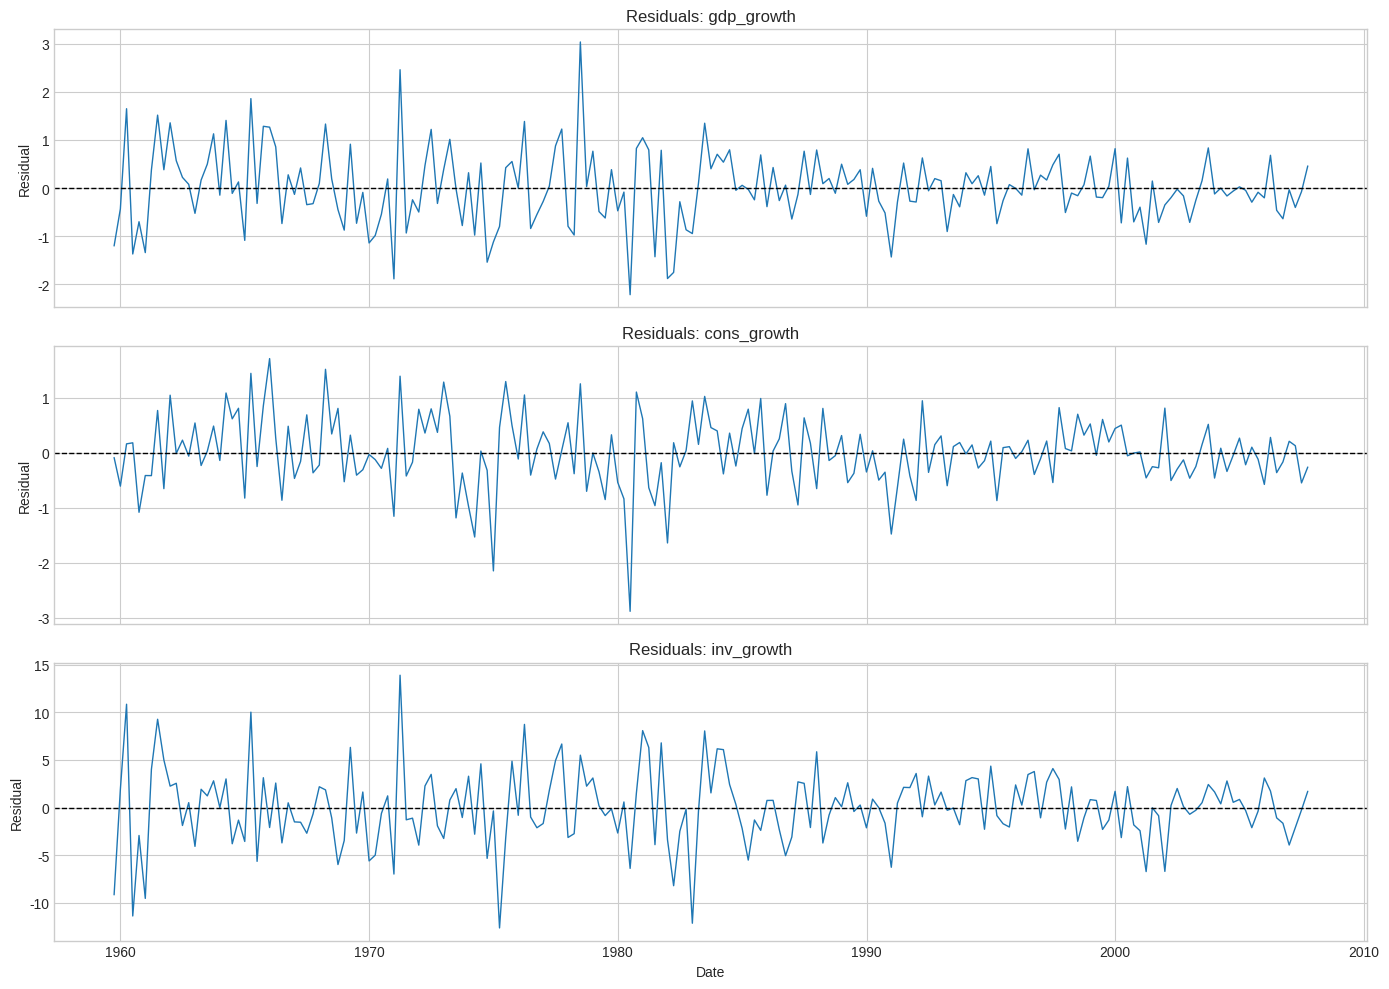

In [14]:
# ============================================
# 14. 변수별 잔차 시각화
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, col in enumerate(resid.columns):
    axes[i].plot(resid.index, resid[col], linewidth=1.0)
    axes[i].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[i].set_title(f"Residuals: {col}")
    axes[i].set_ylabel("Residual")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


## 11. 다변량 예측 수행
이제 학습 구간 끝까지의 데이터를 사용하여 테스트 구간 8분기를 예측합니다.

VAR 예측에서는 마지막 `p`개 시점의 관측치가 필요합니다.


In [15]:
# ============================================
# 15. VAR forecast
# ============================================

forecast_values = var_results.forecast(train.values[-selected_lag:], steps=len(test))

var_forecast = pd.DataFrame(
    forecast_values,
    index=test.index,
    columns=test.columns
)

display(var_forecast.head())


,gdp_growth,cons_growth,inv_growth
2007-12-31,0.457964,0.738487,-1.248278
2008-03-31,0.710034,0.791629,0.569048
2008-06-30,0.762796,0.843991,0.742459
2008-09-30,0.791118,0.858551,0.902342
2008-12-31,0.800577,0.865145,0.947195


## 12. 실제값과 예측값 비교
다변량 시계열에서는 보통 변수별로 예측 그래프를 따로 확인하는 것이 해석에 편리합니다.


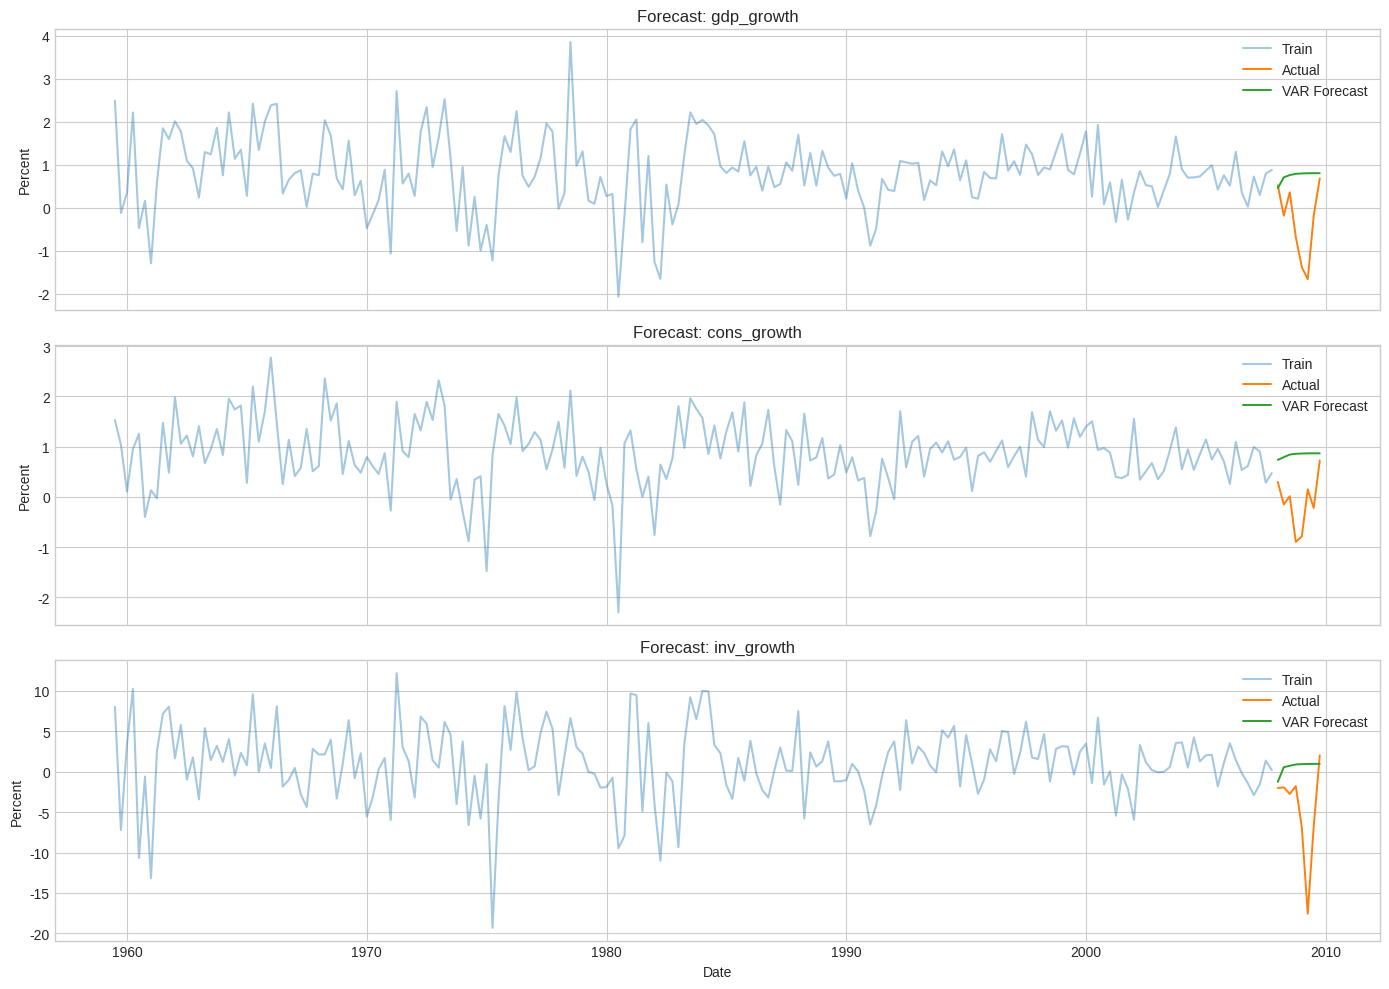

In [16]:
# ============================================
# 16. 변수별 실제값 vs 예측값
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, col in enumerate(test.columns):
    axes[i].plot(train.index, train[col], label="Train", alpha=0.4)
    axes[i].plot(test.index, test[col], label="Actual", linewidth=1.4)
    axes[i].plot(var_forecast.index, var_forecast[col], label="VAR Forecast", linewidth=1.4)
    axes[i].set_title(f"Forecast: {col}")
    axes[i].set_ylabel("Percent")
    axes[i].legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


## 13. 변수별 성능 평가
다변량 예측에서는 하나의 점수로 끝내기보다, 각 변수별 오차를 따로 계산하는 것이 일반적입니다.


In [17]:
# ============================================
# 17. 변수별 평가 함수
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_multivariate(y_true_df, y_pred_df, model_name="Model"):
    rows = []
    for col in y_true_df.columns:
        mae = mean_absolute_error(y_true_df[col], y_pred_df[col])
        rmse = np.sqrt(mean_squared_error(y_true_df[col], y_pred_df[col]))
        rows.append({
            "Model": model_name,
            "Variable": col,
            "MAE": mae,
            "RMSE": rmse
        })
    return pd.DataFrame(rows)


In [18]:
# ============================================
# 18. VAR vs Naive 성능 비교
# ============================================

eval_var = evaluate_multivariate(test, var_forecast, "VAR")
eval_naive = evaluate_multivariate(test, naive_forecast, "Naive")

eval_all = pd.concat([eval_var, eval_naive], ignore_index=True)
display(eval_all.sort_values(["Variable", "RMSE"]))


,Model,Variable,MAE,RMSE
4,Naive,cons_growth,0.643788,0.769047
1,VAR,cons_growth,0.944856,1.076927
0,VAR,gdp_growth,1.073516,1.367190
3,Naive,gdp_growth,1.197483,1.447042
5,Naive,inv_growth,5.362553,7.412552
2,VAR,inv_growth,5.574006,7.843179


## 14. 해석 포인트
여기서 중요한 질문은 단순히 “VAR가 작동했는가?”가 아닙니다.

오히려 다음을 물어야 합니다.

- 어떤 변수에서는 VAR가 Naive보다 나은가?
- 어떤 변수에서는 별 차이가 없는가?
- 투자 성장률처럼 변동성이 큰 변수는 예측이 더 어려운가?
- 상호작용 정보를 넣는 것이 항상 이득인가?

즉, VAR의 가치는 모든 변수에서 무조건 우월한 성능을 내는 데 있지 않고,  
**시스템 전체를 하나의 연결된 구조로 바라보는 분석 프레임**을 제공하는 데 있습니다.


## 15. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- 다변량 시계열은 여러 변수의 상호작용을 함께 다룬다.
- VAR는 각 변수의 과거와 다른 변수들의 과거를 동시에 사용하는 시스템 모형이다.
- 수준 데이터는 로그 차분 등을 통해 정상성에 가까운 형태로 바꾸는 것이 일반적이다.
- 시차 선택은 정보 기준(AIC, BIC)과 자유도 손실을 함께 고려해야 한다.
- 예측 성능은 변수별로 따로 평가하는 것이 자연스럽다.
- 복잡한 다변량 모형도 Naive baseline과 비교하여 실질적 가치를 판단해야 한다.


## 16. 연습문제 (Exercises)

1. `realinv` 대신 `realgovt` 또는 `m1`을 사용하여 다른 3변수 VAR 시스템을 구성하시오.

2. AIC와 BIC가 서로 다른 시차를 선택할 경우, 어떤 이유로 차이가 생기는지 설명하시오.

3. 마지막 8분기 대신 마지막 12분기를 테스트 구간으로 두었을 때 성능이 어떻게 바뀌는지 비교하시오.

4. VAR 예측이 Naive보다 더 좋은 변수와 그렇지 않은 변수를 구분하고, 그 이유를 논의하시오.

5. 왜 다변량 모형이라고 해서 항상 단변량 예측보다 우수하다고 말할 수 없는지 설명하시오.
